<a href="https://colab.research.google.com/github/korkutanapa/OEE_ARTICLE_STUDIES/blob/main/TS_TDA_PREDICTION_BENCHMARK_STUDIES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
# Load the file for time series
data_path = '/content/tda_ready.xlsx'
df = pd.read_excel(data_path)

In [5]:
train_data = df[:-4]  # Last 4 rows for testing
test_data = df[-4:]

In [5]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare the series
train_series = train_data['Operation'].astype(float)
test_series = test_data['Operation'].astype(float)

# Define and fit the ETS Model
# We use error='add', trend='add' as a starting point. Seasonal is set to None as no period was specified.
model = ETSModel(train_series, error='add', trend='add', seasonal=None)
fit = model.fit()

# Forecast the next 4 steps
forecast = fit.forecast(steps=len(test_series))
forecast.index = test_series.index  # Align indices for plotting

# Calculate evaluation metrics
mae = mean_absolute_error(test_series, forecast)
rmse = np.sqrt(mean_squared_error(test_series, forecast))

# Display results
results_df = pd.DataFrame({'Actual': test_series, 'Forecast': forecast})
display(results_df)

print(f"\nMean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

,Actual,Forecast
679,0.543904,-4.461381
680,18.180364,-4.489440
681,13.045591,-4.517498
682,-2.470100,-4.545556



Mean Absolute Error (MAE): 11.8284
Root Mean Squared Error (RMSE): 14.5923


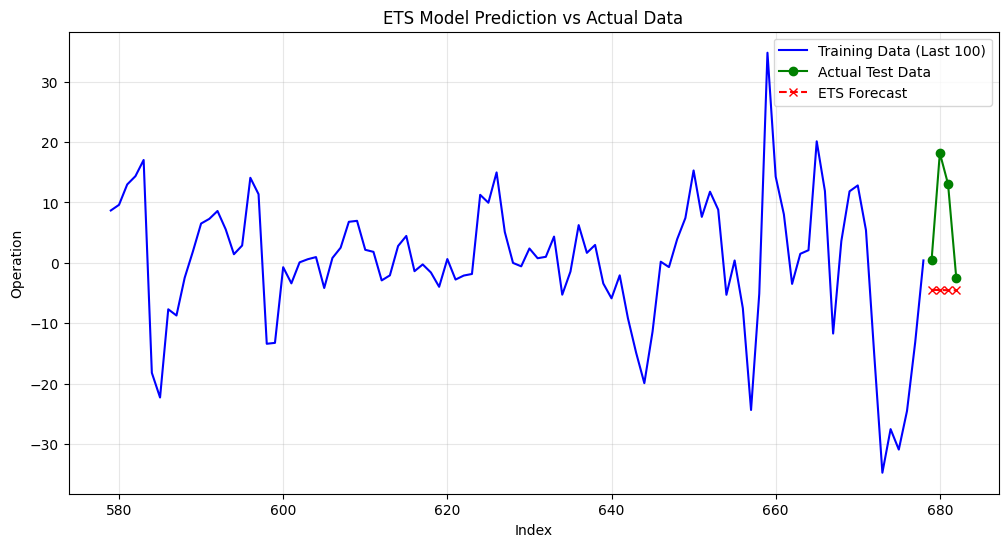

In [6]:
# Plotting the results
plt.figure(figsize=(12, 6))

# Plot a portion of the training data to see the context (last 100 points)
plt.plot(train_series.index[-100:], train_series.iloc[-100:], label='Training Data (Last 100)', color='blue')
plt.plot(test_series.index, test_series, label='Actual Test Data', color='green', marker='o')
plt.plot(forecast.index, forecast, label='ETS Forecast', color='red', linestyle='--', marker='x')

plt.title('ETS Model Prediction vs Actual Data')
plt.xlabel('Index')
plt.ylabel('Operation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
!pip install tbats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.7 MB/s eta 0:00:00


In [8]:
from tbats import TBATS

# Initialize and fit the TBATS model
# TBATS will automatically tune parameters
estimator = TBATS(use_box_cox=None, use_trend=None, use_damped_trend=None, seasonal_periods=None)
model_tbats = estimator.fit(train_series)

# Forecast
forecast_tbats = model_tbats.forecast(steps=len(test_series))
forecast_tbats = pd.Series(forecast_tbats, index=test_series.index)

# Calculate evaluation metrics
mae_tbats = mean_absolute_error(test_series, forecast_tbats)
rmse_tbats = np.sqrt(mean_squared_error(test_series, forecast_tbats))

# Display results
results_tbats_df = pd.DataFrame({'Actual': test_series, 'Forecast': forecast_tbats})
display(results_tbats_df)

print(f"\nTBATS Mean Absolute Error (MAE): {mae_tbats:.4f}")
print(f"TBATS Root Mean Squared Error (RMSE): {rmse_tbats:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Actual,Forecast
679,0.543904,2.766674
680,18.180364,2.126955
681,13.045591,1.601445
682,-2.470100,-0.152853



TBATS Mean Absolute Error (MAE): 8.0094
TBATS Root Mean Squared Error (RMSE): 9.9874


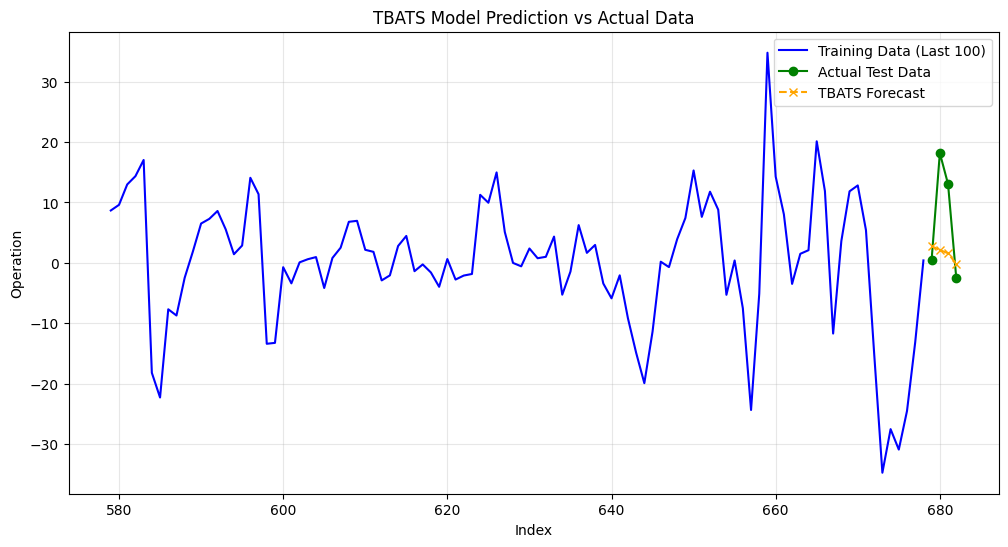

In [9]:
# Plotting the TBATS results
plt.figure(figsize=(12, 6))

plt.plot(train_series.index[-100:], train_series.iloc[-100:], label='Training Data (Last 100)', color='blue')
plt.plot(test_series.index, test_series, label='Actual Test Data', color='green', marker='o')
plt.plot(forecast_tbats.index, forecast_tbats, label='TBATS Forecast', color='orange', linestyle='--', marker='x')

plt.title('TBATS Model Prediction vs Actual Data')
plt.xlabel('Index')
plt.ylabel('Operation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
!pip install git+https://github.com/amazon-science/chronos-forecasting.git
!pip install accelerate

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-429o3fkr
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-429o3fkr
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 7daaa7194c9472f16eab0ea2f9d7eac317002201
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 6.2 MB/s eta 0:00:00
  Created wheel for chronos-forecasting: filename=chronos_forecasting-2.1.0-py3-none-any.whl size=70458 sha256=b266c7bd5f1dc3d835ce8a6a03c1552aa3f8cb64bb0c59a10e441df9029eaa8e
  Stored in directory: /tmp/pip-ephem-wheel-cache-jlq75jz4/wheels/b9/a6/b5/75fca7306751a3bc

In [11]:
import torch
from chronos import ChronosPipeline

# Initialize Chronos Pipeline
# We use 'amazon/chronos-t5-tiny' for a quick demonstration.
# You can swap this with 'small', 'base', or 'large' for potentially better performance.
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

# Prepare context data (Chronos expects a tensor)
# We wrap it in a list because predict expects a batch (batch_size, sequence_length)
context = torch.tensor(train_series.values)

# Forecast
prediction_length = len(test_series)
forecast_chronos_tensor = pipeline.predict(
    context,
    prediction_length,
    num_samples=20,
    temperature=1.0,
    top_k=50,
    top_p=1.0,
)

# The output is (batch_size, num_samples, prediction_length)
# We take the median (quantile 0.5) across samples as the point forecast
forecast_chronos_values = forecast_chronos_tensor[0].quantile(0.5, dim=0).numpy()

# Create Series
forecast_chronos = pd.Series(forecast_chronos_values, index=test_series.index)

# Calculate evaluation metrics
mae_chronos = mean_absolute_error(test_series, forecast_chronos)
rmse_chronos = np.sqrt(mean_squared_error(test_series, forecast_chronos))

# Display results
results_chronos_df = pd.DataFrame({'Actual': test_series, 'Forecast': forecast_chronos})
display(results_chronos_df)

print(f"\nChronos Mean Absolute Error (MAE): {mae_chronos:.4f}")
print(f"Chronos Root Mean Squared Error (RMSE): {rmse_chronos:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

,Actual,Forecast
679,0.543904,1.198363
680,18.180364,1.997271
681,13.045591,2.287783
682,-2.470100,2.614609



Chronos Mean Absolute Error (MAE): 8.1700
Chronos Root Mean Squared Error (RMSE): 10.0487


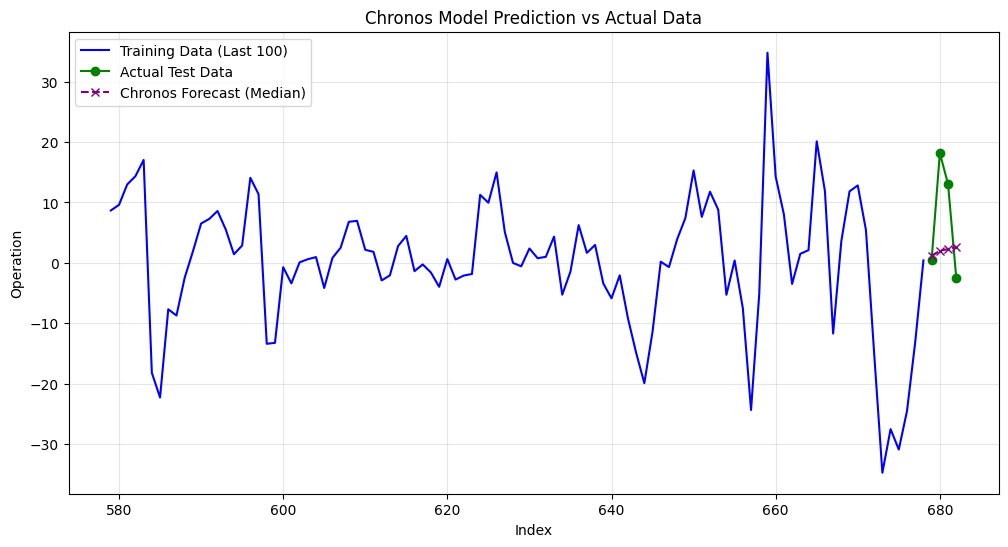

In [12]:
# Plotting the Chronos results
plt.figure(figsize=(12, 6))

plt.plot(train_series.index[-100:], train_series.iloc[-100:], label='Training Data (Last 100)', color='blue')
plt.plot(test_series.index, test_series, label='Actual Test Data', color='green', marker='o')
plt.plot(forecast_chronos.index, forecast_chronos, label='Chronos Forecast (Median)', color='purple', linestyle='--', marker='x')

plt.title('Chronos Model Prediction vs Actual Data')
plt.xlabel('Index')
plt.ylabel('Operation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()